# Week 4: Noise Sensitivity Analysis and Threshold Tuning

**Day 1 - Build a genuine held-out test set + clean baseline**

Goal for today: create a test set the model has truly never seen, train an evaluation model on the remaining 80% using the same approach and hyperparameters that won in Week 3, and record clean (no-noise) performance as today's reference line.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)

import joblib

np.random.seed(42)

In [2]:
DATA_PATH = "ai4i_fused_week2.csv"  # your Week 2 output

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(10000, 22)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,OSF,RNF,timestamp,ambient_temp_C,load_density_pct,ambient_temp_K,temp_differential_K,load_adjusted_torque,wear_per_load,Type_enc
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0,0,1/1/2024 0:00,18.913477,38.362480,292.063477,6.036523,108.732986,0.000000,2
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,0,0,1/1/2024 0:10,18.913477,38.362480,292.063477,6.136523,117.624702,1.150874,1
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,0,0,1/1/2024 0:20,18.913477,38.362480,292.063477,6.036523,125.500222,1.918124,1
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,0,0,1/1/2024 0:30,18.913477,38.362480,292.063477,6.136523,100.349368,2.685374,1
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,0,0,1/1/2024 0:40,17.610902,37.186934,290.760902,7.439098,104.747869,3.346824,1


## Step 1 - Recreate the Week 3 feature set

Same leakage-aware feature list as Week 3 - the five failure-mode flags directly define `Machine failure`, so they stay excluded.

In [3]:
target = "Machine failure"
leak_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
drop_cols = ["UDI", "Product ID", "Type", "timestamp", target] + leak_cols

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols]
y = df[target]

print(f"Using {len(feature_cols)} features")

Using 12 features


## Step 2 - The winning approach and best hyperparameters from Week 3

In [4]:
# Set this to match whatever won in YOUR Week 3 three-way comparison
WINNING_APPROACH = "class_weight"  # or "smote"

tuning_df = pd.read_csv("week3_hyperparameter_tuning_results.csv")
best_row = tuning_df.loc[tuning_df["f1"].idxmax()]
best_params = {
    "num_leaves": int(best_row["num_leaves"]),
    "learning_rate": float(best_row["learning_rate"]),
    "n_estimators": int(best_row["n_estimators"]),
}
print("Winning approach:", WINNING_APPROACH)
print("Best hyperparameters:", best_params)

Winning approach: class_weight
Best hyperparameters: {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 200}


In [5]:
def build_model(params, approach, y_train=None):
    if approach == "smote":
        return ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("clf", lgb.LGBMClassifier(random_state=42, verbose=-1, **params)),
        ])
    else:
        neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
        spw = neg / pos
        return lgb.LGBMClassifier(random_state=42, verbose=-1, scale_pos_weight=spw, **params)

## Step 3 - A fresh, genuinely held-out 80/20 split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {len(X_train)} rows ({y_train.mean()*100:.3f}% failures)")
print(f"Test:  {len(X_test)} rows ({y_test.mean()*100:.3f}% failures)")

Train: 8000 rows (3.388% failures)
Test:  2000 rows (3.400% failures)


## Step 4 - Fit the evaluation model, get the clean baseline

This exact fitted model is what every noise level in Day 2 will be tested against - nothing about the model changes this week, only the input data.

In [7]:
X_train_cleaned = X_train.rename(columns=lambda x: x.replace('[', '_').replace(']', '_').replace('<', '_').replace(' ', '_'))
X_test_cleaned = X_test.rename(columns=lambda x: x.replace('[', '_').replace(']', '_').replace('<', '_').replace(' ', '_'))

eval_model = build_model(best_params, WINNING_APPROACH, y_train)
eval_model.fit(X_train_cleaned, y_train)

proba_clean = eval_model.predict_proba(X_test_cleaned)[:, 1]
pred_clean = eval_model.predict(X_test_cleaned)

clean_baseline = {
    "noise_level": 0.0,
    "recall": recall_score(y_test, pred_clean),
    "precision": precision_score(y_test, pred_clean, zero_division=0),
    "f1": f1_score(y_test, pred_clean),
    "roc_auc": roc_auc_score(y_test, proba_clean),
    "pr_auc": average_precision_score(y_test, proba_clean),
}

print("Clean (no-noise) baseline on held-out test set:")
for k, v in clean_baseline.items():
     print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Clean (no-noise) baseline on held-out test set:
  noise_level: 0.0000
  recall: 0.7647
  precision: 0.8387
  f1: 0.8000
  roc_auc: 0.9696
  pr_auc: 0.8423


## Step 5 - Save everything Day 2 needs

In [8]:
joblib.dump(eval_model, "week4_eval_model.joblib")
X_test.to_csv("week4_X_test.csv", index=False)
y_test.to_csv("week4_y_test.csv", index=False)
pd.DataFrame([clean_baseline]).to_csv("week4_clean_baseline.csv", index=False)

print("Saved week4_eval_model.joblib, week4_X_test.csv, week4_y_test.csv, week4_clean_baseline.csv")

Saved week4_eval_model.joblib, week4_X_test.csv, week4_y_test.csv, week4_clean_baseline.csv


## Day 2 - Inject synthetic noise, measure the damage

Goal: empirically characterize how much the model's performance degrades as sensor readings get noisier, instead of just claiming "it's robust." Noise is added only to the held-out test set (`X_test` from Day 1) - the model itself never changes, so any difference in the numbers below is caused purely by the noisier input.



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)

np.random.seed(42)

eval_model = joblib.load("week4_eval_model.joblib")
X_test = pd.read_csv("week4_X_test.csv")
y_test = pd.read_csv("week4_y_test.csv").iloc[:, 0]

print(X_test.shape, y_test.shape)

(2000, 12) (2000,)


### Step 1 - Decide which columns actually get noise

`Type_enc` is a categorical code (0, 1, 2 for product quality variant), not a continuous sensor reading - adding Gaussian noise to it would just produce meaningless fractional category values. Noise only makes sense on the genuinely continuous sensor and context features.

In [10]:
noise_cols = [c for c in X_test.columns if c != "Type_enc"]
print(f"Adding noise to {len(noise_cols)} continuous features:")
print(noise_cols)

Adding noise to 11 continuous features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'ambient_temp_C', 'load_density_pct', 'ambient_temp_K', 'temp_differential_K', 'load_adjusted_torque', 'wear_per_load']


### Step 2 - Inject noise scaled to each feature's own spread

A fixed noise amount (say, +/-5 units) would be huge for a feature that normally varies by 2 and trivial for one that varies by 200. Scaling the noise to a percentage of each feature's own standard deviation keeps the disturbance comparable across very different sensors.

In [11]:
def add_gaussian_noise(X, cols, noise_level, random_state=None):
    rng = np.random.default_rng(random_state)
    X_noisy = X.copy()
    for col in cols:
        std = X[col].std()
        noise = rng.normal(0, noise_level * std, size=len(X))
        X_noisy[col] = X_noisy[col] + noise
    return X_noisy

### Step 3 - Evaluate the same fixed model at each noise level

In [12]:
noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30]
results = []

for level in noise_levels:
    X_eval = X_test if level == 0.0 else add_gaussian_noise(X_test, noise_cols, level, random_state=42)

    proba = eval_model.predict_proba(X_eval)[:, 1]
    pred = eval_model.predict(X_eval)

    results.append({
        "noise_level": level,
        "recall": recall_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
    })

noise_sensitivity = pd.DataFrame(results)
noise_sensitivity.round(4)

,noise_level,recall,precision,f1,roc_auc,pr_auc
0,0.00,0.7647,0.8387,0.8000,0.9696,0.8423
1,0.05,0.7206,0.8033,0.7597,0.9687,0.7680
2,0.10,0.7353,0.7143,0.7246,0.9662,0.7416
3,0.20,0.6324,0.5309,0.5772,0.9411,0.5669
4,0.30,0.5294,0.4235,0.4706,0.9173,0.4480


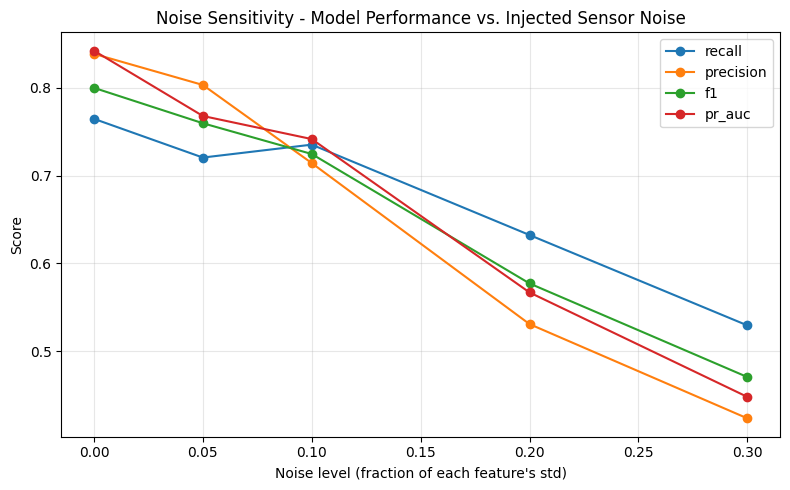

In [13]:
plt.figure(figsize=(8, 5))
for metric in ["recall", "precision", "f1", "pr_auc"]:
    plt.plot(noise_sensitivity["noise_level"], noise_sensitivity[metric], marker="o", label=metric)
plt.xlabel("Noise level (fraction of each feature's std)")
plt.ylabel("Score")
plt.title("Noise Sensitivity - Model Performance vs. Injected Sensor Noise")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("week4_noise_sensitivity.png", dpi=150)
plt.show()

In [14]:
noise_sensitivity.to_csv("week4_noise_sensitivity.csv", index=False)
print("Saved week4_noise_sensitivity.csv and week4_noise_sensitivity.png")

Saved week4_noise_sensitivity.csv and week4_noise_sensitivity.png


### Reading the curve

- **Flat lines** across noise levels mean the model's decisions barely depend on small fluctuations in the raw sensor values - a genuinely robust signal
- **A steep early drop** (performance falls a lot even at 5-10% noise) means the model is leaning on fine-grained precision in the sensor readings that real-world sensor drift would wipe out
- **Recall and precision dropping at different rates** matters for Day 4 - if recall falls faster than precision under noise, your chosen threshold may need to shift to compensate

One honest caveat worth a line in your report: this uses independent Gaussian noise per feature, which is a simplification. Real sensor degradation is often correlated across features (e.g., a failing thermocouple drifts steadily rather than jittering randomly) - this experiment measures a reasonable first-order robustness signal, not a worst-case guarantee.

## Day 3 - Precision-Recall curves, clean vs. noisy

Goal: look at the model's behavior across *every* possible threshold at once, not just the single 0.5 cutoff used so far - then see how that whole curve shifts once Day 2's worst-case noise is applied.

**Why PR curve instead of ROC curve here?** ROC curves include true negatives in their calculation, and with failures under 2% of the data, true negatives are so abundant that ROC curves tend to look deceptively good - they can stay near-perfect even when the model is actually bad at catching the rare failure cases. The Precision-Recall curve only looks at how the model handles the positive (failure) class, which is exactly what matters for this problem.



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import precision_recall_curve, average_precision_score

np.random.seed(42)

eval_model = joblib.load("week4_eval_model.joblib")
X_test = pd.read_csv("week4_X_test.csv")
y_test = pd.read_csv("week4_y_test.csv").iloc[:, 0]

noise_cols = [c for c in X_test.columns if c != "Type_enc"]

def add_gaussian_noise(X, cols, noise_level, random_state=None):
    rng = np.random.default_rng(random_state)
    X_noisy = X.copy()
    for col in cols:
        std = X[col].std()
        noise = rng.normal(0, noise_level * std, size=len(X))
        X_noisy[col] = X_noisy[col] + noise
    return X_noisy

WORST_NOISE_LEVEL = 0.30  # the highest level tested on Day 2
X_test_noisy = add_gaussian_noise(X_test, noise_cols, WORST_NOISE_LEVEL, random_state=42)

print("Clean test set and 30%-noise version ready.")

Clean test set and 30%-noise version ready.


### Step 1 - Compute both curves

In [16]:
proba_clean = eval_model.predict_proba(X_test)[:, 1]
precision_clean, recall_clean, thresholds_clean = precision_recall_curve(y_test, proba_clean)
ap_clean = average_precision_score(y_test, proba_clean)

proba_noisy = eval_model.predict_proba(X_test_noisy)[:, 1]
precision_noisy, recall_noisy, thresholds_noisy = precision_recall_curve(y_test, proba_noisy)
ap_noisy = average_precision_score(y_test, proba_noisy)

print(f"Average precision - clean: {ap_clean:.4f} | 30% noise: {ap_noisy:.4f}")

Average precision - clean: 0.8423 | 30% noise: 0.4480


### Step 2 - Plot them on the same axes

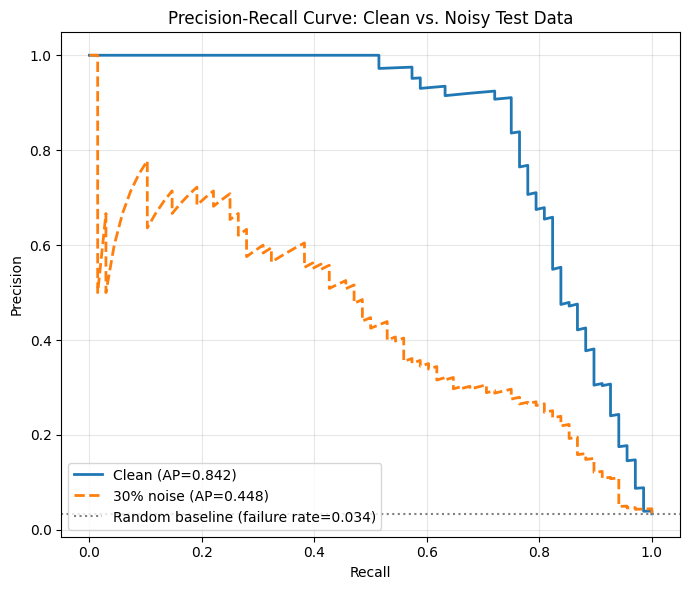

In [17]:
plt.figure(figsize=(7, 6))
plt.plot(recall_clean, precision_clean, label=f"Clean (AP={ap_clean:.3f})", linewidth=2)
plt.plot(recall_noisy, precision_noisy, label=f"30% noise (AP={ap_noisy:.3f})", linewidth=2, linestyle="--")
plt.axhline(y=y_test.mean(), color="gray", linestyle=":",
            label=f"Random baseline (failure rate={y_test.mean():.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Clean vs. Noisy Test Data")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("week4_pr_curves.png", dpi=150)
plt.show()

### Reading the curves

- The top-right corner (high precision *and* high recall) is the ideal - no real model sits there, but the closer the curve hugs it, the better
- The gray dotted line is what a random guess would score - if either curve drops close to it at some recall level, the model has essentially nothing useful left to say at that point
- Compare the *shapes*, not just the AP numbers: does the noisy curve sit uniformly below the clean one everywhere (the model degraded across the board), or only in a specific region (e.g. it still works fine at low recall but falls apart once you push for high recall)? That distinction matters directly for Day 4 - if the curves diverge most at high-recall settings, that's exactly where your threshold choice gets riskiest under real-world noise.

In [18]:
pr_clean_df = pd.DataFrame({
    "precision": precision_clean, "recall": recall_clean,
    "threshold": np.append(thresholds_clean, np.nan)
})
pr_noisy_df = pd.DataFrame({
    "precision": precision_noisy, "recall": recall_noisy,
    "threshold": np.append(thresholds_noisy, np.nan)
})

pr_clean_df.to_csv("week4_pr_curve_clean.csv", index=False)
pr_noisy_df.to_csv("week4_pr_curve_noisy.csv", index=False)
print("Saved week4_pr_curve_clean.csv and week4_pr_curve_noisy.csv")

Saved week4_pr_curve_clean.csv and week4_pr_curve_noisy.csv


## Day 4 - Threshold tuning with a real cost trade-off

Goal: pick a decision threshold deliberately, based on what missing a failure actually costs versus what a false alarm costs - then check whether that exact threshold still holds up once the sensor readings get noisy.



In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    recall_score, precision_score, f1_score, confusion_matrix
)

np.random.seed(42)

eval_model = joblib.load("week4_eval_model.joblib")
X_test = pd.read_csv("week4_X_test.csv")
y_test = pd.read_csv("week4_y_test.csv").iloc[:, 0]

pr_clean_df = pd.read_csv("week4_pr_curve_clean.csv")
pr_noisy_df = pd.read_csv("week4_pr_curve_noisy.csv")

noise_cols = [c for c in X_test.columns if c != "Type_enc"]

def add_gaussian_noise(X, cols, noise_level, random_state=None):
    rng = np.random.default_rng(random_state)
    X_noisy = X.copy()
    for col in cols:
        std = X[col].std()
        noise = rng.normal(0, noise_level * std, size=len(X))
        X_noisy[col] = X_noisy[col] + noise
    return X_noisy

WORST_NOISE_LEVEL = 0.30
X_test_noisy = add_gaussian_noise(X_test, noise_cols, WORST_NOISE_LEVEL, random_state=42)

proba_clean = eval_model.predict_proba(X_test)[:, 1]
proba_noisy = eval_model.predict_proba(X_test_noisy)[:, 1]

print("Ready.")

Ready.


### Step 1 - State the trade-off explicitly

In a predictive maintenance setting:
- A **false negative** (missed failure) usually means unplanned downtime, possible safety risk, and emergency repair costs - expensive
- A **false positive** (false alarm) means a maintenance crew checks a machine that turns out fine - a wasted inspection, annoying but cheap by comparison

Because missing a failure costs far more than a false alarm, the right threshold is usually well *below* the default 0.5. We'll pick it two ways and see if they agree.

In [20]:
TARGET_RECALL = 0.90  # "catch at least 90% of real failures"

valid = pr_clean_df.dropna(subset=["threshold"])
candidates = valid[valid["recall"] >= TARGET_RECALL]

if len(candidates) > 0:
    best_by_recall = candidates.loc[candidates["precision"].idxmax()]
    threshold_recall_method = best_by_recall["threshold"]
    print(f"Threshold for >= {TARGET_RECALL:.0%} recall: {threshold_recall_method:.4f}")
    print(f"  -> precision at this threshold: {best_by_recall['precision']:.4f}, recall: {best_by_recall['recall']:.4f}")
else:
    threshold_recall_method = None
    print(f"No threshold reaches {TARGET_RECALL:.0%} recall on the clean curve - consider a lower target.")

Threshold for >= 90% recall: 0.0018
  -> precision at this threshold: 0.3085, recall: 0.9118


In [21]:
BETA = 2  # weight recall twice as heavily as precision

fbeta_scores = (1 + BETA**2) * (valid["precision"] * valid["recall"]) / (BETA**2 * valid["precision"] + valid["recall"] + 1e-12)
best_idx = fbeta_scores.idxmax()
threshold_fbeta_method = valid.loc[best_idx, "threshold"]

print(f"Threshold maximizing F{BETA}: {threshold_fbeta_method:.4f}")
print(f"  -> precision: {valid.loc[best_idx, 'precision']:.4f}, recall: {valid.loc[best_idx, 'recall']:.4f}, F{BETA}: {fbeta_scores[best_idx]:.4f}")

Threshold maximizing F2: 0.1074
  -> precision: 0.6588, recall: 0.8235, F2: 0.7843


In [22]:
# Target-recall is the more directly interpretable choice for a maintenance team
# ("we catch at least 90% of failures") - use it as primary, fall back to the F-beta
# threshold only if the recall target was unreachable.
FINAL_THRESHOLD = threshold_recall_method if threshold_recall_method is not None else threshold_fbeta_method
print(f"Final chosen threshold: {FINAL_THRESHOLD:.4f}  (default would have been 0.5)")

Final chosen threshold: 0.0018  (default would have been 0.5)


### Step 2 - Does this threshold survive contact with noise?

Apply this exact threshold - not a re-tuned one - to both the clean probabilities and the 30%-noise probabilities from Day 3. This is the real test: in production you fix a threshold once. If performance collapses once readings get noisy, that's a deployment risk worth flagging now.

In [23]:
def evaluate_at_threshold(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    return {
        "recall": recall_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred),
        "false_alarms (FP)": cm[0, 1],
        "missed_failures (FN)": cm[1, 0],
    }

clean_at_threshold = evaluate_at_threshold(y_test, proba_clean, FINAL_THRESHOLD)
noisy_at_threshold = evaluate_at_threshold(y_test, proba_noisy, FINAL_THRESHOLD)

threshold_comparison = pd.DataFrame({"clean": clean_at_threshold, "30%_noise": noisy_at_threshold})
threshold_comparison

,clean,30%_noise
recall,0.911765,0.852941
precision,0.308458,0.212454
f1,0.460967,0.340176
false_alarms (FP),139.000000,215.000000
missed_failures (FN),6.000000,10.000000


If recall and missed-failure count stay close between the two columns, the threshold is robust enough to trust as-is. If missed failures jump noticeably under noise, that's worth calling out explicitly in your report rather than glossing over.

### Step 3 - How much would the "true" optimal threshold have shifted?

You can't actually retune a deployed threshold in real time based on how noisy the sensors happen to be that day - but it's informative to check, in hindsight, how far off your clean-data threshold was from what would have been optimal if you'd had the noisy curve in advance. A big gap quantifies real risk; a small one means your choice is fairly noise-tolerant.

In [24]:
noisy_valid = pr_noisy_df.dropna(subset=["threshold"])
noisy_candidates = noisy_valid[noisy_valid["recall"] >= TARGET_RECALL]

if len(noisy_candidates) > 0:
    best_noisy = noisy_candidates.loc[noisy_candidates["precision"].idxmax()]
    print(f"Threshold that would be optimal ON the noisy data: {best_noisy['threshold']:.4f}")
    print(f"Threshold actually chosen (on clean data):          {FINAL_THRESHOLD:.4f}")
    print(f"Gap: {abs(best_noisy['threshold'] - FINAL_THRESHOLD):.4f}")
else:
    print(f"Even the best possible threshold on noisy data cannot reach {TARGET_RECALL:.0%} recall - "
          f"a real limitation worth noting in your report.")

Threshold that would be optimal ON the noisy data: 0.0002
Threshold actually chosen (on clean data):          0.0018
Gap: 0.0015


In [25]:
final_decision = pd.Series({
    "target_recall": TARGET_RECALL,
    "beta_for_fbeta_check": BETA,
    "final_threshold": FINAL_THRESHOLD,
})
final_decision.to_csv("week4_threshold_decision.csv")
threshold_comparison.to_csv("week4_threshold_comparison.csv")
print("Saved week4_threshold_decision.csv and week4_threshold_comparison.csv")

Saved week4_threshold_decision.csv and week4_threshold_comparison.csv


## Day 5 - Final write-up:



In [26]:
clean_baseline = pd.read_csv("week4_clean_baseline.csv")
noise_sensitivity = pd.read_csv("week4_noise_sensitivity.csv")
threshold_decision = pd.read_csv("week4_threshold_decision.csv", index_col=0).squeeze()
threshold_comparison = pd.read_csv("week4_threshold_comparison.csv", index_col=0)

print(clean_baseline)
print()
print(noise_sensitivity)
print()
print(threshold_decision)
print()
print(threshold_comparison)

   noise_level    recall  precision   f1   roc_auc    pr_auc
0          0.0  0.764706    0.83871  0.8  0.969622  0.842294

   noise_level    recall  precision        f1   roc_auc    pr_auc
0         0.00  0.764706   0.838710  0.800000  0.969622  0.842294
1         0.05  0.720588   0.803279  0.759690  0.968723  0.767950
2         0.10  0.735294   0.714286  0.724638  0.966204  0.741642
3         0.20  0.632353   0.530864  0.577181  0.941062  0.566927
4         0.30  0.529412   0.423529  0.470588  0.917298  0.447964

target_recall           0.900000
beta_for_fbeta_check    2.000000
final_threshold         0.001759
Name: 0, dtype: float64

                           clean   30%_noise
recall                  0.911765    0.852941
precision               0.308458    0.212454
f1                      0.460967    0.340176
false_alarms (FP)     139.000000  215.000000
missed_failures (FN)    6.000000   10.000000


## Project complete

Four weeks, one coherent pipeline: EDA -> contextual data fusion with a proven ablation study -> a correctly-validated, tuned, imbalance-aware LightGBM model -> an empirically robustness-tested, cost-justified deployment threshold. Every step has saved artifacts and a written rationale, not just code.
